In [1]:
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
k_list = [5,16 ,32 ,64 ,80 ,96 ,128 ,160 ,200 ,240 ,280 ,320 ,340 ,400]
#k_list = [5]
import re
from scipy import stats
import numpy as np
def extract_scores(text):
    # Extracting the required scores from the text with a very flexible comet score pattern
    results = {}

    # Splitting the text based on the dynamic path pattern
    path_pattern = r'/raid/lyu/.*?score:'
    split_text = re.split(path_pattern, text)
    if len(split_text) < 2:
        return "No valid path or score data found in the text."

    json_data_part = split_text[0].strip()
    scores_part = 'score:' + split_text[1].strip()

    # Extracting JSON data for BLEU and chrF2
    try:
        json_data = eval(json_data_part)
        for data in json_data:
            if data["name"] in ["BLEU", "chrF2"]:
                results[data["name"]] = data["score"]
    except:
        return "Error in parsing JSON data."

    # Extracting scores from the scores part with a very flexible pattern for comet score
    comet_score = re.search(r'score:\s*([0-9.]+)', scores_part)
    entity_accuracy = re.search(r'Total Accuracy:\s*([0-9.]+)', scores_part)
    bertscore_f1 = re.search(r'bert-base-chinese.*F1:\s*([0-9.]+)', scores_part)
    bleurt_score = re.search(r'([0-9.]+)\s*$', scores_part)

    if comet_score:
        results["comet"] = float(comet_score.group(1))
    if entity_accuracy:
        results["entity Accuracy"] = float(entity_accuracy.group(1))
    if bertscore_f1:
        results["bertscore F1"] = float(bertscore_f1.group(1))
    if bleurt_score:
        results["BLEURT"] = float(bleurt_score.group(1))

    return results


In [3]:
#en-zh high resource
path_prefix="/raid/lyu/QEBT/test_dev/test_high_base/"
ref_file="/raid/lyu/en-zh/test/zh/test.zho"

In [4]:
#read data
bs_model_score = {}
bs_mbr_score = {}
bs_qe_score = {}
for k in tqdm(k_list):
    with open(path_prefix+'/bs/{}/ct2_output.hypo_{}.score'.format(k,k),"r",encoding="utf-8") as f:
        bs_model_score[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'/mbr_bs/output_{}/mbr.score'.format(k),"r",encoding="utf-8") as f:
        tmp_list = [json.loads(line.strip()) for line in f.readlines()]
        #reshape
        bs_mbr_score[k] = []
        for i in range(len(tmp_list)):
            bs_mbr_score[k].extend(tmp_list[i])
    with open(path_prefix+'/qe_bs/output_{}/qe.output.score'.format(k),"r",encoding="utf-8") as f:
        bs_qe_score[k] = [float(line.strip()) for line in f.readlines()]
    assert len(bs_model_score[k]) == len(bs_mbr_score[k]) == len(bs_qe_score[k])
as_model_score = {}
as_mbr_score = {}
as_qe_score = {}
for k in tqdm(k_list):
    with open(path_prefix+'/as/{}/ct2_output.hypo_{}.score'.format(k,k),"r",encoding="utf-8") as f:
        as_model_score[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'/mbr_as/output_{}/mbr.score'.format(k),"r",encoding="utf-8") as f:
        tmp_list = [json.loads(line.strip()) for line in f.readlines()]
        #reshape
        as_mbr_score[k] = []
        for i in range(len(tmp_list)):
            as_mbr_score[k].extend(tmp_list[i])
    with open(path_prefix+'/qe_as/output_{}/qe.output.score'.format(k),"r",encoding="utf-8") as f:
        as_qe_score[k] = [float(line.strip()) for line in f.readlines()]
    assert len(as_model_score[k]) == len(as_mbr_score[k]) == len(as_qe_score[k])

100%|██████████| 14/14 [00:52<00:00,  3.72s/it]


In [5]:
bs_pearsonr_mbr_modelscore = []
bs_pearsonr_qe_modelscore = []
bs_pearsonr_qe_mbrs = []
for k in tqdm(k_list,desc="calculating pearsonr",total=len(k_list)):
    bs_pearsonr_mbr_modelscore.append(stats.pearsonr(bs_mbr_score[k],bs_model_score[k])[0])
    bs_pearsonr_qe_modelscore.append(stats.pearsonr(bs_qe_score[k],bs_model_score[k])[0])
    bs_pearsonr_qe_mbrs.append(stats.pearsonr(bs_qe_score[k],bs_mbr_score[k])[0])
as_pearsonr_mbr_modelscore = []
as_pearsonr_qe_modelscore = []
as_pearsonr_qe_mbrs = []
for k in tqdm(k_list,desc="calculating pearsonr",total=len(k_list)):
    as_pearsonr_mbr_modelscore.append(stats.pearsonr(as_mbr_score[k],as_model_score[k])[0])
    as_pearsonr_qe_modelscore.append(stats.pearsonr(as_qe_score[k],as_model_score[k])[0])
    as_pearsonr_qe_mbrs.append(stats.pearsonr(as_qe_score[k],as_mbr_score[k])[0])

calculating pearsonr: 100%|██████████| 14/14 [00:09<00:00,  1.51it/s]


In [6]:
#ランク相関係数
from scipy.stats import spearmanr
from scipy.stats import rankdata
bs_qe_rank={}
bs_mbr_rank={}
bs_model_rank={}
bs_spearmanr_qe_modelscore = []
bs_spearmanr_mbr_modelscore = []
bs_spearmanr_qe_mbrs = []
for k in tqdm(k_list):
    bs_qe_rank[k]=[]
    bs_mbr_rank[k]=[]
    bs_model_rank[k]=[]
    for i in range(len(bs_mbr_score[k])):
        tmp_qe=bs_qe_score[k][i*k:(i+1)*k]
        tmp_mbr=bs_mbr_score[k][i*k:(i+1)*k]
        tmp_model=bs_model_score[k][i*k:(i+1)*k]
        ranked_qe=rankdata(tmp_qe, method='dense').astype(int).tolist()
        ranked_qe=[k+1-x for x in ranked_qe]
        ranked_mbr=rankdata(tmp_mbr, method='dense').astype(int).tolist()
        ranked_mbr=[k+1-x for x in ranked_mbr]
        ranked_model=rankdata(tmp_model, method='dense').astype(int).tolist()
        ranked_model=[k+1-x for x in ranked_model]
        bs_qe_rank[k].extend(ranked_qe)
        bs_mbr_rank[k].extend(ranked_mbr)
        bs_model_rank[k].extend(ranked_model)

    assert len(bs_qe_rank[k])==len(bs_mbr_rank[k])==len(bs_model_rank[k])==len(bs_qe_score[k])==len(bs_mbr_score[k])==len(bs_model_score[k])
    bs_spearmanr_qe_modelscore.append(spearmanr(bs_qe_rank[k],bs_model_rank[k])[0])
    bs_spearmanr_mbr_modelscore.append(spearmanr(bs_mbr_rank[k],bs_model_rank[k])[0])
    bs_spearmanr_qe_mbrs.append(spearmanr(bs_qe_rank[k],bs_mbr_rank[k])[0])
    
as_qe_rank={}
as_mbr_rank={}
as_model_rank={}
as_spearmanr_qe_modelscore = []
as_spearmanr_mbr_modelscore = []
as_spearmanr_qe_mbrs = []
for k in tqdm(k_list):
    as_mbr_rank[k]=[]
    as_qe_rank[k]=[]
    as_model_rank[k]=[]
    for i in range(len(as_mbr_score[k])):
        tmp_qe=as_qe_score[k][i*k:(i+1)*k]
        tmp_mbr=as_mbr_score[k][i*k:(i+1)*k]
        tmp_model=as_model_score[k][i*k:(i+1)*k]
        ranked_qe=rankdata(tmp_qe, method='dense').astype(int).tolist()
        ranked_qe=[k+1-x for x in ranked_qe]
        ranked_mbr=rankdata(tmp_mbr, method='dense').astype(int).tolist()
        ranked_mbr=[k+1-x for x in ranked_mbr]
        ranked_model=rankdata(tmp_model, method='dense').astype(int).tolist()
        ranked_model=[k+1-x for x in ranked_model]
        as_qe_rank[k].extend(ranked_qe)
        as_mbr_rank[k].extend(ranked_mbr)
        as_model_rank[k].extend(ranked_model)
        
    assert len(as_qe_rank[k])==len(as_mbr_rank[k])==len(as_model_rank[k])==len(as_qe_score[k])==len(as_mbr_score[k])==len(as_model_score[k])
    as_spearmanr_qe_modelscore.append(spearmanr(as_qe_rank[k],as_model_rank[k])[0])
    as_spearmanr_mbr_modelscore.append(spearmanr(as_mbr_rank[k],as_model_rank[k])[0])
    as_spearmanr_qe_mbrs.append(spearmanr(as_qe_rank[k],as_mbr_rank[k])[0])


100%|██████████| 14/14 [1:17:56<00:00, 334.01s/it]


In [32]:
from scipy.stats import spearmanr
from scipy.stats import rankdata
from multiprocessing import Pool

# Define your existing data structures
bs_qe_rank = {}
bs_mbr_rank = {}
bs_model_rank = {}
bs_spearmanr_qe_modelscore = []
bs_spearmanr_mbr_modelscore = []
bs_spearmanr_qe_mbrs = []

as_qe_rank={}
as_mbr_rank={}
as_model_rank={}
as_spearmanr_qe_modelscore = []
as_spearmanr_mbr_modelscore = []
as_spearmanr_qe_mbrs = []

# Your existing data like bs_qe_score, bs_mbr_score, bs_model_score, and k_list should be defined here

# Define a function to handle the computation for each k
def process_k_as(k):
    qe_rank, mbr_rank, model_rank = [], [], []
    for i in range(len(bs_mbr_score[k]) // k):
        tmp_qe = as_qe_score[k][i*k:(i+1)*k]
        tmp_mbr = as_mbr_score[k][i*k:(i+1)*k]
        tmp_model = as_model_score[k][i*k:(i+1)*k]

        ranked_qe = rankdata(tmp_qe, method='dense').astype(int).tolist()
        ranked_qe = [k+1-x for x in ranked_qe]
        ranked_mbr = rankdata(tmp_mbr, method='dense').astype(int).tolist()
        ranked_mbr = [k+1-x for x in ranked_mbr]
        ranked_model = rankdata(tmp_model, method='dense').astype(int).tolist()
        ranked_model = [k+1-x for x in ranked_model]

        qe_rank.extend(ranked_qe)
        mbr_rank.extend(ranked_mbr)
        model_rank.extend(ranked_model)

    return (qe_rank, mbr_rank, model_rank, 
            spearmanr(qe_rank, model_rank)[0], 
            spearmanr(mbr_rank, model_rank)[0], 
            spearmanr(qe_rank, mbr_rank)[0])
    

def process_k_bs(k):
    qe_rank, mbr_rank, model_rank = [], [], []
    for i in range(len(bs_mbr_score[k]) // k):
        tmp_qe = bs_qe_score[k][i*k:(i+1)*k]
        tmp_mbr = bs_mbr_score[k][i*k:(i+1)*k]
        tmp_model = bs_model_score[k][i*k:(i+1)*k]

        ranked_qe = rankdata(tmp_qe, method='dense').astype(int).tolist()
        ranked_qe = [k+1-x for x in ranked_qe]
        ranked_mbr = rankdata(tmp_mbr, method='dense').astype(int).tolist()
        ranked_mbr = [k+1-x for x in ranked_mbr]
        ranked_model = rankdata(tmp_model, method='dense').astype(int).tolist()
        ranked_model = [k+1-x for x in ranked_model]

        qe_rank.extend(ranked_qe)
        mbr_rank.extend(ranked_mbr)
        model_rank.extend(ranked_model)

    return (qe_rank, mbr_rank, model_rank, 
            spearmanr(qe_rank, model_rank)[0], 
            spearmanr(mbr_rank, model_rank)[0], 
            spearmanr(qe_rank, mbr_rank)[0])

# Use multiprocessing to parallelize the loop
if __name__ == "__main__":
    with Pool() as pool:
        results = list(tqdm(pool.imap(process_k_bs, k_list), total=len(k_list)))

    # Unpack results and update the data structures
    for k, (qe_rank, mbr_rank, model_rank, sr_qe_model, sr_mbr_model, sr_qe_mbr) in zip(k_list, results):
        bs_qe_rank[k] = qe_rank
        bs_mbr_rank[k] = mbr_rank
        bs_model_rank[k] = model_rank
        bs_spearmanr_qe_modelscore.append(sr_qe_model)
        bs_spearmanr_mbr_modelscore.append(sr_mbr_model)
        bs_spearmanr_qe_mbrs.append(sr_qe_mbr)
    
    with Pool() as pool:
        results = list(tqdm(pool.imap(process_k_as, k_list), total=len(k_list)))
    
    for k, (qe_rank, mbr_rank, model_rank, sr_qe_model, sr_mbr_model, sr_qe_mbr) in zip(k_list, results):
        as_qe_rank[k] = qe_rank
        as_mbr_rank[k] = mbr_rank
        as_model_rank[k] = model_rank
        as_spearmanr_qe_modelscore.append(sr_qe_model)
        as_spearmanr_mbr_modelscore.append(sr_mbr_model)
        as_spearmanr_qe_mbrs.append(sr_qe_mbr)


100%|██████████| 14/14 [00:11<00:00,  1.21it/s]


In [11]:
#save data to cache
import os
cache_path = path_prefix+"cache/"
if not os.path.exists(cache_path):
    os.makedirs(cache_path)
for decoding in ["bs","as"]:
    for score_type in ["model","mbr","qe"]:
        with open(cache_path+"{}_{}_rank.json".format(decoding,score_type),"w",encoding="utf-8") as f:
            json.dump(eval("{}_{}_rank".format(decoding,score_type)),f)
        print("save {}_{}_rank.json".format(decoding,score_type))
        

save bs_model_rank.json
save bs_mbr_rank.json
save bs_qe_rank.json
save as_model_rank.json
save as_mbr_rank.json
save as_qe_rank.json


In [ ]:
#load data from cache
cache_path = path_prefix+"cache/"
for decoding in ["bs","as"]:
    for score_type in ["model","mbr","qe"]:
        with open(cache_path+"{}_{}_rank.json".format(decoding,score_type),"r",encoding="utf-8") as f:
            exec("{}_{}_rank = json.load(f)".format(decoding,score_type))
    exec("{}_spearmanr_qe_modelscore = []".format(decoding))
    exec("{}_spearmanr_mbr_modelscore = []".format(decoding))
    exec("{}_spearmanr_qe_mbrs = []".format(decoding))
    for k in tqdm(k_list):
        exec("{}_spearmanr_qe_modelscore.append(spearmanr({}_qe_rank[k],{}_model_rank[k])[0])".format(decoding,decoding,decoding))
        exec("{}_spearmanr_mbr_modelscore.append(spearmanr({}_mbr_rank[k],{}_model_rank[k])[0])".format(decoding,decoding,decoding))
        exec("{}_spearmanr_qe_mbrs.append(spearmanr({}_qe_rank[k],{}_mbr_rank[k])[0])".format(decoding,decoding,decoding))

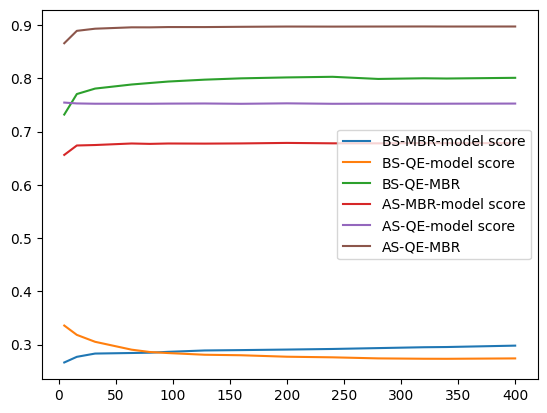

In [33]:
#分别把三个相关系数的折线图画出来
#画在同一张图上，用不同颜色的线表示
#每条线标注名字
plt.figure()
plt.plot(k_list,bs_pearsonr_mbr_modelscore,label="BS-MBR-model score")
plt.plot(k_list,bs_pearsonr_qe_modelscore,label="BS-QE-model score")
plt.plot(k_list,bs_pearsonr_qe_mbrs,label="BS-QE-MBR")
plt.plot(k_list,as_pearsonr_mbr_modelscore,label="AS-MBR-model score")
plt.plot(k_list,as_pearsonr_qe_modelscore,label="AS-QE-model score")
plt.plot(k_list,as_pearsonr_qe_mbrs,label="AS-QE-MBR")
plt.legend()
plt.show()


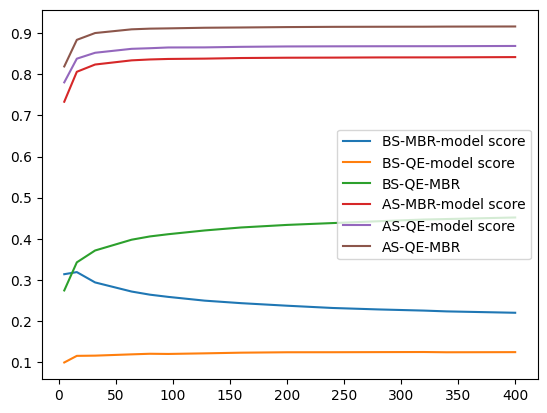

In [34]:
plt.figure()
plt.plot(k_list,bs_spearmanr_mbr_modelscore,label="BS-MBR-model score")
plt.plot(k_list,bs_spearmanr_qe_modelscore,label="BS-QE-model score")
plt.plot(k_list,bs_spearmanr_qe_mbrs,label="BS-QE-MBR")
plt.plot(k_list,as_spearmanr_mbr_modelscore,label="AS-MBR-model score")
plt.plot(k_list,as_spearmanr_qe_modelscore,label="AS-QE-model score")
plt.plot(k_list,as_spearmanr_qe_mbrs,label="AS-QE-MBR")
plt.legend()
plt.show()

In [14]:
bs_output_text_mbr={}
bs_output_text_qe={}
bs_output_text_bs={}
for k in tqdm(k_list):
    with open(path_prefix+'/mbr_bs/output_{}/mbr.output'.format(k,k),"r",encoding="utf-8") as f:
        bs_output_text_mbr[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/qe_bs/output_{}/qe.output'.format(k),"r",encoding="utf-8") as f:
        bs_output_text_qe[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/bs/{}/hypo_1'.format(k),"r",encoding="utf-8") as f:
        bs_output_text_bs[k] = [line.strip() for line in f.readlines()]
    assert len(bs_output_text_mbr[k]) == len(bs_output_text_qe[k]) == len(bs_output_text_bs[k])
    
as_output_text_mbr={}
as_output_text_qe={}
as_output_text_bs={}
for k in tqdm(k_list):
    with open(path_prefix+'/mbr_as/output_{}/mbr.output'.format(k,k),"r",encoding="utf-8") as f:
        as_output_text_mbr[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/qe_as/output_{}/qe.output'.format(k),"r",encoding="utf-8") as f:
        as_output_text_qe[k] = [line.strip() for line in f.readlines()]
    with open(path_prefix+'/as/{}/hypo_1'.format(k),"r",encoding="utf-8") as f:
        as_output_text_bs[k] = [line.strip() for line in f.readlines()]
    assert len(as_output_text_mbr[k]) == len(as_output_text_qe[k]) == len(as_output_text_bs[k])


100%|██████████| 14/14 [00:03<00:00,  3.75it/s]


In [15]:
#统计长度分布
bs_mean_len_mbr = []
bs_mean_len_qe = []
bs_mean_len_bs = []
bs_std_len_mbr = []
bs_std_len_qe = []
bs_std_len_bs = []
for k in k_list:
    bs_mean_len_mbr.append(np.mean([len(line) for line in bs_output_text_mbr[k]]))
    bs_mean_len_qe.append(np.mean([len(line) for line in bs_output_text_qe[k]]))
    bs_mean_len_bs.append(np.mean([len(line) for line in bs_output_text_bs[k]]))
    bs_std_len_mbr.append(np.std([len(line) for line in bs_output_text_mbr[k]]))
    bs_std_len_qe.append(np.std([len(line) for line in bs_output_text_qe[k]]))
    bs_std_len_bs.append(np.std([len(line) for line in bs_output_text_bs[k]]))
as_mean_len_mbr = []
as_mean_len_qe = []
as_mean_len_bs = []
as_std_len_mbr = []
as_std_len_qe = []
as_std_len_bs = []
for k in k_list:
    as_mean_len_mbr.append(np.mean([len(line) for line in as_output_text_mbr[k]]))
    as_mean_len_qe.append(np.mean([len(line) for line in as_output_text_qe[k]]))
    as_mean_len_bs.append(np.mean([len(line) for line in as_output_text_bs[k]]))
    as_std_len_mbr.append(np.std([len(line) for line in as_output_text_mbr[k]]))
    as_std_len_qe.append(np.std([len(line) for line in as_output_text_qe[k]]))
    as_std_len_bs.append(np.std([len(line) for line in as_output_text_bs[k]]))
ref_len=[]   
with open(ref_file,"r",encoding="utf-8") as f:
    ref_text = [line.strip() for line in f.readlines()]
    ref_len=[len(line) for line in ref_text]
ref_mean_len = np.mean([len(line) for line in ref_text])
ref_std_len = np.std([len(line) for line in ref_text])

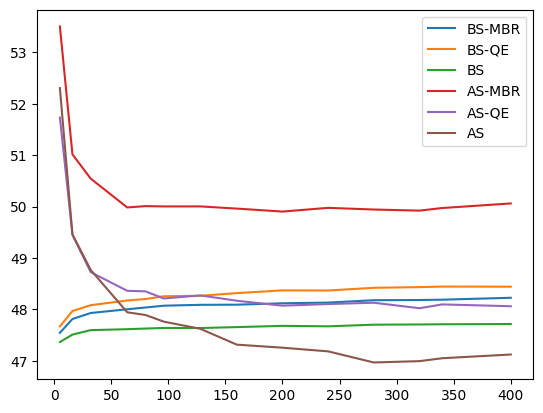

In [16]:
#画出长度分布的折线图
plt.figure()
plt.plot(k_list,bs_mean_len_mbr,label="BS-MBR")
plt.plot(k_list,bs_mean_len_qe,label="BS-QE")
plt.plot(k_list,bs_mean_len_bs,label="BS")
plt.plot(k_list,as_mean_len_mbr,label="AS-MBR")
plt.plot(k_list,as_mean_len_qe,label="AS-QE")
plt.plot(k_list,as_mean_len_bs,label="AS")
#画一条虚线表示参考译文的长度
plt.plot(k_list,[ref_mean_len]*len(k_list),label="ref",linestyle="--")
plt.legend()
plt.show()

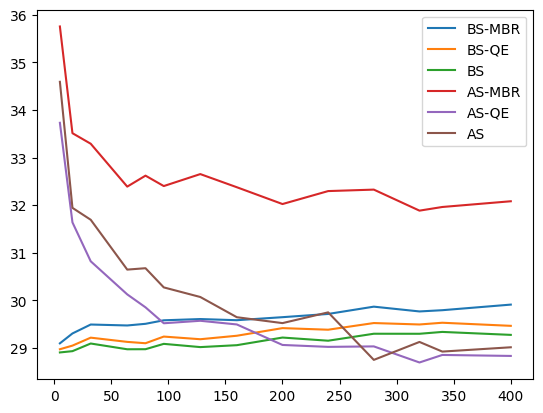

In [17]:
#标准差的折线图
plt.figure()
plt.plot(k_list,bs_std_len_mbr,label="BS-MBR")
plt.plot(k_list,bs_std_len_qe,label="BS-QE")
plt.plot(k_list,bs_std_len_bs,label="BS")
plt.plot(k_list,as_std_len_mbr,label="AS-MBR")
plt.plot(k_list,as_std_len_qe,label="AS-QE")
plt.plot(k_list,as_std_len_bs,label="AS")
plt.legend()
plt.show()

In [14]:
#MBR/QEスコアの一番高いhypoは何割がBSの結果の上位１つに入っているか

mbr_top1=[]
mbr_top2=[]
qe_top1=[]
qe_top2=[]
for k in tqdm(k_list):
    count_top1=0
    count_top2=0
    for i in range(len(mbr_score[k])//k):
        cand_scores=mbr_score[k][i*k:(i+1)*k]
        max_score=max(cand_scores)
        max_index=cand_scores.index(max_score)
        if max_index==0:
            count_top1+=1
            count_top2+=1
        elif max_index==1:
            count_top2+=1
    mbr_top1.append(count_top1/(len(mbr_score[k])//k))
    mbr_top2.append(count_top2/(len(mbr_score[k])//k))
    count_top1=0
    count_top2=0
    for i in range(len(qe_score[k])//k):
        cand_scores=qe_score[k][i*k:(i+1)*k]
        max_score=max(cand_scores)
        max_index=cand_scores.index(max_score)
        if max_index==0:
            count_top1+=1
            count_top2+=1
        elif max_index==1:
            count_top2+=1
    qe_top1.append(count_top1/(len(qe_score[k])//k))
    qe_top2.append(count_top2/(len(qe_score[k])//k))


100%|██████████| 14/14 [00:01<00:00,  7.96it/s]


  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:15<00:00,  1.09s/it]


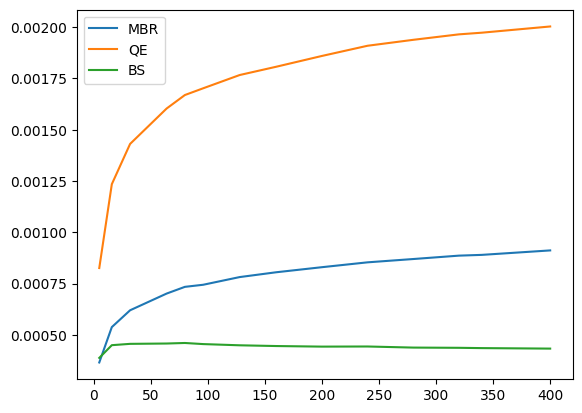

In [15]:
#计算MBR，QE，BS的大小为k的组的组内方差
mbr_var=[]
qe_var=[]
bs_var=[]
for k in tqdm(k_list):
    tmp_mbr=[]
    tmp_qe=[]
    tmp_bs=[]
    for i in range(len(mbr_score[k])//k):
        cand_scores=mbr_score[k][i*k:(i+1)*k]
        tmp_mbr.append(np.var(cand_scores))
        cand_scores=qe_score[k][i*k:(i+1)*k]
        tmp_qe.append(np.var(cand_scores))
        cand_scores=model_score[k][i*k:(i+1)*k]
        tmp_bs.append(np.var(cand_scores))
    mbr_var.append(np.mean(tmp_mbr))
    qe_var.append(np.mean(tmp_qe))
    bs_var.append(np.mean(tmp_bs))
plt.figure()
plt.plot(k_list,mbr_var,label="MBR")
plt.plot(k_list,qe_var,label="QE")
plt.plot(k_list,bs_var,label="BS")
plt.legend()
plt.show()

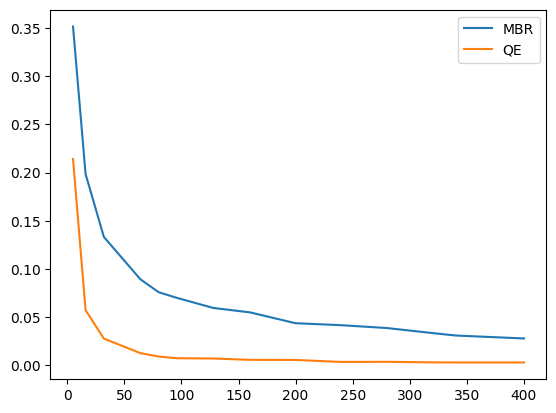

In [16]:
#top-1
plt.figure()
plt.plot(k_list,mbr_top1,label="MBR")
plt.plot(k_list,qe_top1,label="QE")
plt.legend()
plt.show()

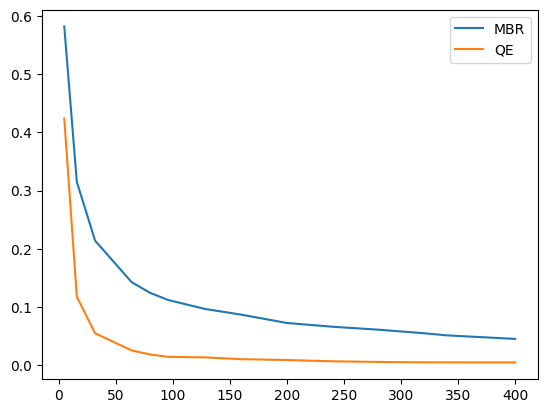

In [17]:
#top-2
plt.figure()
plt.plot(k_list,mbr_top2,label="MBR")
plt.plot(k_list,qe_top2,label="QE")
plt.legend()
plt.show()

In [18]:
#提取评价指标
bs_mbr_metrics = {}
bs_qe_metrics = {}
bs_metrics = {}
for k in tqdm(k_list):
    with open(path_prefix+'/mbr_bs/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_mbr_metrics[k] = [extract_scores(f.read())]
        with open(path_prefix+'/mbr_bs/output_{}/num_score.log'.format(k),"r",encoding="utf-8") as f2:
            num_acc=re.search(r'Total Accuracy:\s*([0-9.]+)', f2.read())
            num_acc=float(num_acc.group(1))
            bs_mbr_metrics[k][0]["num_acc"]=num_acc
    with open(path_prefix+'/qe_bs/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_qe_metrics[k] = [extract_scores(f.read())]
        with open(path_prefix+'/qe_bs/output_{}/num_score.log'.format(k),"r",encoding="utf-8") as f2:
            num_acc=re.search(r'Total Accuracy:\s*([0-9.]+)', f2.read())
            num_acc=float(num_acc.group(1))
            bs_qe_metrics[k][0]["num_acc"]=num_acc
    with open(path_prefix+'/bs/{}/score.log'.format(k),"r",encoding="utf-8") as f:
        bs_metrics[k] = [extract_scores(f.read())]
        with open(path_prefix+'/bs/{}/num_score.log'.format(k),"r",encoding="utf-8") as f2:
            num_acc=re.search(r'Total Accuracy:\s*([0-9.]+)', f2.read())
            num_acc=float(num_acc.group(1))
            bs_metrics[k][0]["num_acc"]=num_acc
    assert len(bs_mbr_metrics[k]) == len(bs_qe_metrics[k]) == len(bs_metrics[k])
as_mbr_metrics = {}
as_qe_metrics = {}
as_metrics = {}
for k in tqdm(k_list):
    with open(path_prefix+'/mbr_as/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        as_mbr_metrics[k] = [extract_scores(f.read())]
        with open(path_prefix+'/mbr_as/output_{}/num_score.log'.format(k),"r",encoding="utf-8") as f2:
            num_acc=re.search(r'Total Accuracy:\s*([0-9.]+)', f2.read())
            num_acc=float(num_acc.group(1))
            as_mbr_metrics[k][0]["num_acc"]=num_acc
    with open(path_prefix+'/qe_as/output_{}/score.log'.format(k),"r",encoding="utf-8") as f:
        as_qe_metrics[k] = [extract_scores(f.read())]
        with open(path_prefix+'/qe_as/output_{}/num_score.log'.format(k),"r",encoding="utf-8") as f2:
            num_acc=re.search(r'Total Accuracy:\s*([0-9.]+)', f2.read())
            num_acc=float(num_acc.group(1))
            as_qe_metrics[k][0]["num_acc"]=num_acc
    with open(path_prefix+'/as/{}/score.log'.format(k),"r",encoding="utf-8") as f:
        as_metrics[k] = [extract_scores(f.read())]
        with open(path_prefix+'/as/{}/num_score.log'.format(k),"r",encoding="utf-8") as f2:
            num_acc=re.search(r'Total Accuracy:\s*([0-9.]+)', f2.read())
            num_acc=float(num_acc.group(1))
            as_metrics[k][0]["num_acc"]=num_acc
    assert len(as_mbr_metrics[k]) == len(as_qe_metrics[k]) == len(as_metrics[k])

  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 14.02it/s]


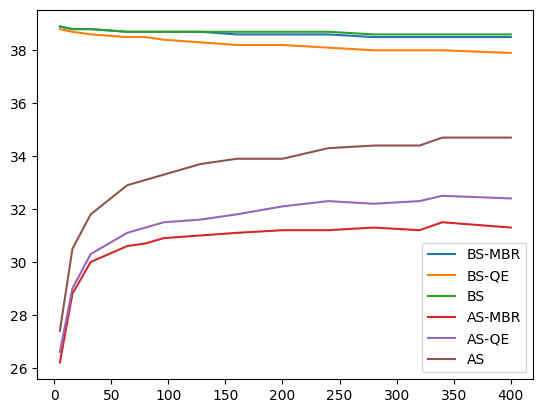

In [19]:
#BLEU
bs_mbr_bleu = []
as_mbr_bleu = []
bs_qe_bleu = []
as_qe_bleu = []
bs_bleu = []
as_bleu = []
for k in k_list:
    bs_mbr_bleu.append(bs_mbr_metrics[k][0]["BLEU"])
    bs_qe_bleu.append(bs_qe_metrics[k][0]["BLEU"])
    bs_bleu.append(bs_metrics[k][0]["BLEU"])
    as_mbr_bleu.append(as_mbr_metrics[k][0]["BLEU"])
    as_qe_bleu.append(as_qe_metrics[k][0]["BLEU"])
    as_bleu.append(as_metrics[k][0]["BLEU"])
plt.figure()
plt.plot(k_list,bs_mbr_bleu,label="BS-MBR")
plt.plot(k_list,bs_qe_bleu,label="BS-QE")
plt.plot(k_list,bs_bleu,label="BS")
plt.plot(k_list,as_mbr_bleu,label="AS-MBR")
plt.plot(k_list,as_qe_bleu,label="AS-QE")
plt.plot(k_list,as_bleu,label="AS")
plt.legend()
plt.show()


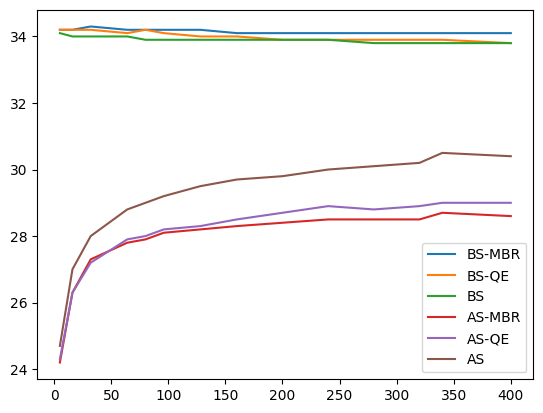

In [20]:
#chrF2
bs_mbr_chrf2 = []
bs_qe_chrf2 = []
bs_chrf2 = []
as_mbr_chrf2 = []
as_qe_chrf2 = []
as_chrf2 = []
for k in k_list:
    bs_mbr_chrf2.append(bs_mbr_metrics[k][0]["chrF2"])
    bs_qe_chrf2.append(bs_qe_metrics[k][0]["chrF2"])
    bs_chrf2.append(bs_metrics[k][0]["chrF2"])
    as_mbr_chrf2.append(as_mbr_metrics[k][0]["chrF2"])
    as_qe_chrf2.append(as_qe_metrics[k][0]["chrF2"])
    as_chrf2.append(as_metrics[k][0]["chrF2"])
plt.figure()
plt.plot(k_list,bs_mbr_chrf2,label="BS-MBR")
plt.plot(k_list,bs_qe_chrf2,label="BS-QE")
plt.plot(k_list,bs_chrf2,label="BS")
plt.plot(k_list,as_mbr_chrf2,label="AS-MBR")
plt.plot(k_list,as_qe_chrf2,label="AS-QE")
plt.plot(k_list,as_chrf2,label="AS")
plt.legend()
plt.show()

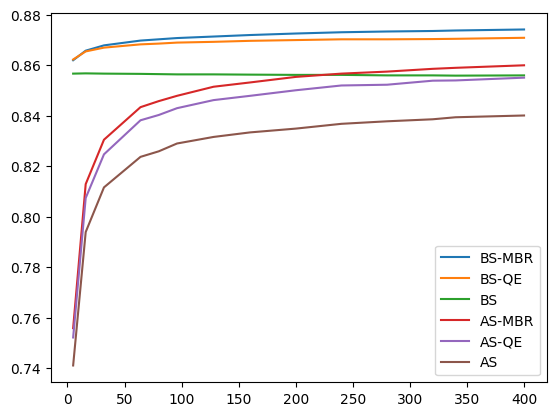

In [23]:
#comet
bs_mbr_comet = []
as_mbr_comet = []
bs_qe_comet = []
as_qe_comet = []
bs_comet = []
as_comet = []
for k in k_list:
    bs_mbr_comet.append(bs_mbr_metrics[k][0]["comet"])
    bs_qe_comet.append(bs_qe_metrics[k][0]["comet"])
    bs_comet.append(bs_metrics[k][0]["comet"])
    as_mbr_comet.append(as_mbr_metrics[k][0]["comet"])
    as_qe_comet.append(as_qe_metrics[k][0]["comet"])
    as_comet.append(as_metrics[k][0]["comet"])
plt.figure()
plt.plot(k_list,bs_mbr_comet,label="BS-MBR")
plt.plot(k_list,bs_qe_comet,label="BS-QE")
plt.plot(k_list,bs_comet,label="BS")
plt.plot(k_list,as_mbr_comet,label="AS-MBR")
plt.plot(k_list,as_qe_comet,label="AS-QE")
plt.plot(k_list,as_comet,label="AS")
plt.legend()
plt.show()

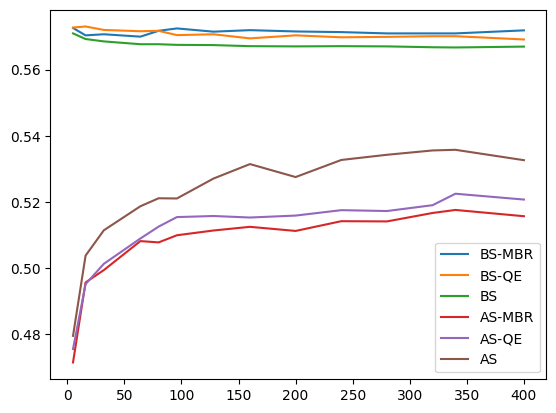

In [25]:
#entity accuracy
bs_mbr_entity_accuracy = []
as_mbr_entity_accuracy = []
bs_qe_entity_accuracy = []
as_qe_entity_accuracy = []
bs_entity_accuracy = []
as_entity_accuracy = []
for k in k_list:
    bs_mbr_entity_accuracy.append(bs_mbr_metrics[k][0]["entity Accuracy"])
    bs_qe_entity_accuracy.append(bs_qe_metrics[k][0]["entity Accuracy"])
    bs_entity_accuracy.append(bs_metrics[k][0]["entity Accuracy"])
    as_mbr_entity_accuracy.append(as_mbr_metrics[k][0]["entity Accuracy"])
    as_qe_entity_accuracy.append(as_qe_metrics[k][0]["entity Accuracy"])
    as_entity_accuracy.append(as_metrics[k][0]["entity Accuracy"])
plt.figure()
plt.plot(k_list,bs_mbr_entity_accuracy,label="BS-MBR")
plt.plot(k_list,bs_qe_entity_accuracy,label="BS-QE")
plt.plot(k_list,bs_entity_accuracy,label="BS")
plt.plot(k_list,as_mbr_entity_accuracy,label="AS-MBR")
plt.plot(k_list,as_qe_entity_accuracy,label="AS-QE")
plt.plot(k_list,as_entity_accuracy,label="AS")
plt.legend()
plt.show()

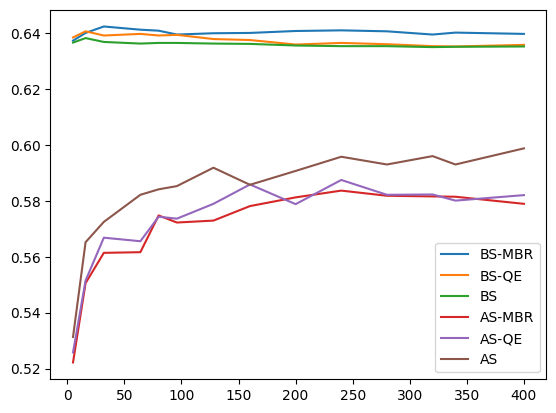

In [26]:
#num_acc
bs_mbr_num_acc = []
as_mbr_num_acc = []
bs_qe_num_acc = []
as_qe_num_acc = []
bs_num_acc = []
as_num_acc = []
for k in k_list:
    bs_mbr_num_acc.append(bs_mbr_metrics[k][0]["num_acc"])
    bs_qe_num_acc.append(bs_qe_metrics[k][0]["num_acc"])
    bs_num_acc.append(bs_metrics[k][0]["num_acc"])
    as_mbr_num_acc.append(as_mbr_metrics[k][0]["num_acc"])
    as_qe_num_acc.append(as_qe_metrics[k][0]["num_acc"])
    as_num_acc.append(as_metrics[k][0]["num_acc"])
plt.figure()
plt.plot(k_list,bs_mbr_num_acc,label="BS-MBR")
plt.plot(k_list,bs_qe_num_acc,label="BS-QE")
plt.plot(k_list,bs_num_acc,label="BS")
plt.plot(k_list,as_mbr_num_acc,label="AS-MBR")
plt.plot(k_list,as_qe_num_acc,label="AS-QE")
plt.plot(k_list,as_num_acc,label="AS")
plt.legend()
plt.show()

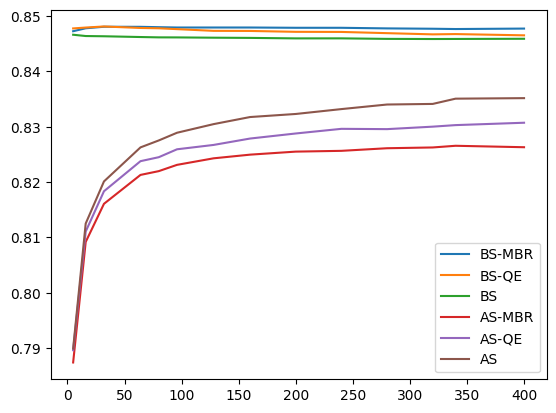

In [27]:
#bertscore F1
bs_mbr_bertscore_f1 = []
as_mbr_bertscore_f1 = []
bs_qe_bertscore_f1 = []
as_qe_bertscore_f1 = []
bs_bertscore_f1 = []
as_bertscore_f1 = []
for k in k_list:
    bs_mbr_bertscore_f1.append(bs_mbr_metrics[k][0]["bertscore F1"])
    bs_qe_bertscore_f1.append(bs_qe_metrics[k][0]["bertscore F1"])
    bs_bertscore_f1.append(bs_metrics[k][0]["bertscore F1"])
    as_mbr_bertscore_f1.append(as_mbr_metrics[k][0]["bertscore F1"])
    as_qe_bertscore_f1.append(as_qe_metrics[k][0]["bertscore F1"])
    as_bertscore_f1.append(as_metrics[k][0]["bertscore F1"])
plt.figure()
plt.plot(k_list,bs_mbr_bertscore_f1,label="BS-MBR")
plt.plot(k_list,bs_qe_bertscore_f1,label="BS-QE")
plt.plot(k_list,bs_bertscore_f1,label="BS")
plt.plot(k_list,as_mbr_bertscore_f1,label="AS-MBR")
plt.plot(k_list,as_qe_bertscore_f1,label="AS-QE")
plt.plot(k_list,as_bertscore_f1,label="AS")
plt.legend()
plt.show()

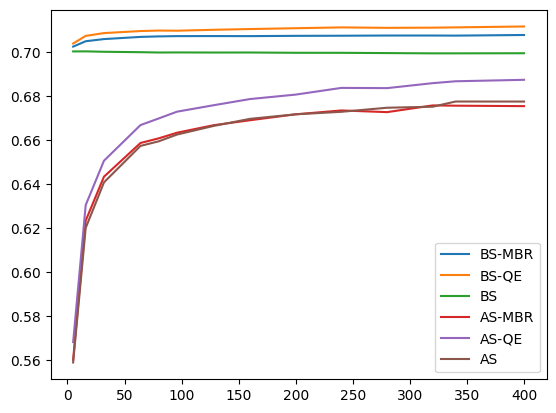

In [28]:
#BLEURT
bs_mbr_bleurt = []
as_mbr_bleurt = []
bs_qe_bleurt = []
as_qe_bleurt = []
bs_bleurt = []
as_bleurt = []
for k in k_list:
    bs_mbr_bleurt.append(bs_mbr_metrics[k][0]["BLEURT"])
    bs_qe_bleurt.append(bs_qe_metrics[k][0]["BLEURT"])
    bs_bleurt.append(bs_metrics[k][0]["BLEURT"])
    as_mbr_bleurt.append(as_mbr_metrics[k][0]["BLEURT"])
    as_qe_bleurt.append(as_qe_metrics[k][0]["BLEURT"])
    as_bleurt.append(as_metrics[k][0]["BLEURT"])
plt.figure()
plt.plot(k_list,bs_mbr_bleurt,label="BS-MBR")
plt.plot(k_list,bs_qe_bleurt,label="BS-QE")
plt.plot(k_list,bs_bleurt,label="BS")
plt.plot(k_list,as_mbr_bleurt,label="AS-MBR")
plt.plot(k_list,as_qe_bleurt,label="AS-QE")
plt.plot(k_list,as_bleurt,label="AS")
plt.legend()
plt.show()

In [20]:
#perplexity
mbr_perplexity = {}
qe_perplexity = {}
bs_perplexity = {}
for k in k_list:
    with open(path_prefix+'/mbr_bs/output_{}/mbr.output.perplexity'.format(k,k),"r",encoding="utf-8") as f:
        mbr_perplexity[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'/qe_bs/output_{}/qe.output.perplexity'.format(k),"r",encoding="utf-8") as f:
        qe_perplexity[k] = [float(line.strip()) for line in f.readlines()]
    with open(path_prefix+'/bs/{}/hypo_1.perplexity'.format(k),"r",encoding="utf-8") as f:
        bs_perplexity[k] = [float(line.strip()) for line in f.readlines()]
    assert len(mbr_perplexity[k]) == len(qe_perplexity[k]) == len(bs_perplexity[k])
mean_mbr=[]
mean_qe=[]
mean_bs=[]
std_mbr=[]
std_qe=[]
std_bs=[]
for k in k_list:
    mean_mbr.append(np.mean(mbr_perplexity[k]))
    mean_qe.append(np.mean(qe_perplexity[k]))
    mean_bs.append(np.mean(bs_perplexity[k]))
    std_mbr.append(np.std(mbr_perplexity[k]))
    std_qe.append(np.std(qe_perplexity[k]))
    std_bs.append(np.std(bs_perplexity[k]))

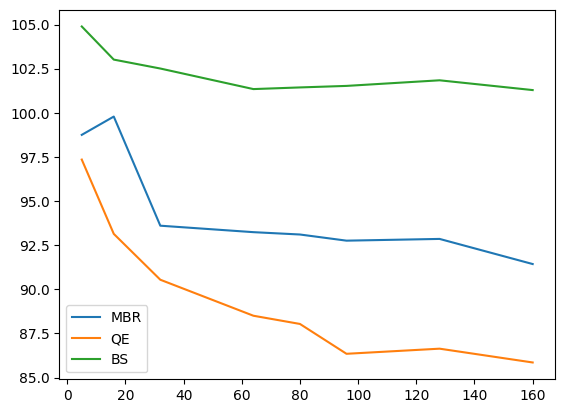

In [5]:
plt.figure()
plt.plot(k_list,mean_mbr,label="MBR")
plt.plot(k_list,mean_qe,label="QE")
plt.plot(k_list,mean_bs,label="BS")
plt.legend()
plt.show()